# Euler Angles

Euler angles are three angular parameters that describe the orientation of a rigid body in three-dimensional space. These angles represent a sequence of rotations around the axes of a coordinate system and allow the transformation of the orientation of one reference frame relative to another. The three Euler angles correspond to rotations about specific axes in a defined order, and their combination fully defines the orientation of the object.

In 3D rotations, we work with three angles corresponding to the yaw, pitch, and roll:

* Yaw (ψ): The angle of rotation about the Z-axis.

* Pitch (θ): The angle of rotation about the Y-axis.

* Roll (ϕ): The angle of rotation about the X-axis.


There are a total of 12 possible combinations of Euler rotations. The most commonly used combinations are 313, 321, and 123. Below is the list of all 12 combinations, expressed in both Latin characters, numbers, and Greek characters:

| Rotation (Latin) | Rotation (Numerical) | Angles (Greek)      |
|------------------|----------------------|---------------------|
| ZYX              | 321                  | ψ, θ, ϕ             |
| XYZ              | 123                  | ϕ, θ, ψ             |
| ZXZ              | 313                  | ψ, θ, ψ             |
| ZXY              | 231                  | ψ, ϕ, θ             |
| XYZ              | 132                  | ϕ, ψ, θ             |
| YZX              | 213                  | θ, ψ, ϕ             |
| XZX              | 131                  | ϕ, ψ, ϕ             |
| XYX              | 212                  | ϕ, θ, ϕ             |
| YXY              | 232                  | θ, ϕ, θ             |
| ZYZ              | 323                  | ψ, ϕ, ψ             |
| XZY              | 312                  | ϕ, ψ, θ             |
| YZX              | 231                  | θ, ϕ, ψ             |


---

In [1]:
!pip install numpy sympy matplotlib

import numpy as np
import sympy as sm
from sympy.physics.vector import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

In [25]:
phi, theta, psi = sm.symbols('phi theta psi')

# Define the rotation matrices for each axis

# Rotation around the X-axis by angle phi
Rx = sm.Matrix([
    [1, 0, 0],
    [0, sm.cos(phi), -sm.sin(phi)],
    [0, sm.sin(phi), sm.cos(phi)]
])

# Rotation around the Y-axis by angle theta
Ry = sm.Matrix([
    [sm.cos(theta), 0, sm.sin(theta)],
    [0, 1, 0],
    [-sm.sin(theta), 0, sm.cos(theta)]
])

# Rotation around the Z-axis by angle psi
Rz = sm.Matrix([
    [sm.cos(psi), -sm.sin(psi), 0],
    [sm.sin(psi), sm.cos(psi), 0],
    [0, 0, 1]
])

print("Rotation Matrix for X-axis (Rx):")
sm.pprint(Rx)
print("\n")

print("\nRotation Matrix for Y-axis (Ry):")
sm.pprint(Ry)
print("\n")

print("\nRotation Matrix for Z-axis (Rz):")
sm.pprint(Rz)


Rotation Matrix for X-axis (Rx):
⎡1    0        0   ⎤
⎢                  ⎥
⎢0  cos(φ)  -sin(φ)⎥
⎢                  ⎥
⎣0  sin(φ)  cos(φ) ⎦



Rotation Matrix for Y-axis (Ry):
⎡cos(θ)   0  sin(θ)⎤
⎢                  ⎥
⎢   0     1    0   ⎥
⎢                  ⎥
⎣-sin(θ)  0  cos(θ)⎦



Rotation Matrix for Z-axis (Rz):
⎡cos(ψ)  -sin(ψ)  0⎤
⎢                  ⎥
⎢sin(ψ)  cos(ψ)   0⎥
⎢                  ⎥
⎣  0        0     1⎦


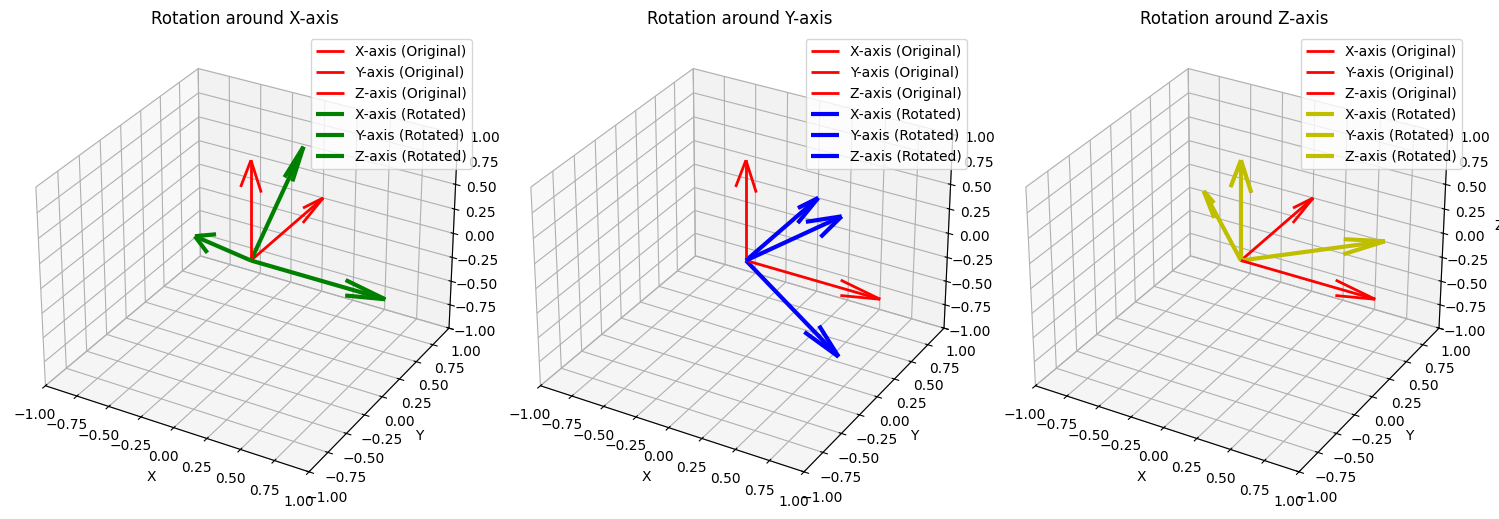

In [26]:
axes = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

Rx_np = sm.lambdify(phi, Rx, "numpy")
Ry_np = sm.lambdify(theta, Ry, "numpy")
Rz_np = sm.lambdify(psi, Rz, "numpy")

# Set rotation angles in radians
phi_val = np.pi / 4  # 45 degrees
theta_val = np.pi / 4 
psi_val = np.pi / 4

Rx_rot = Rx_np(phi_val) @ axes.T
Ry_rot = Ry_np(theta_val) @ axes.T
Rz_rot = Rz_np(psi_val) @ axes.T

fig = plt.figure(figsize=(15, 5))


# Plot for Rotation around X-axis
ax = fig.add_subplot(131, projection='3d')

ax.quiver(0, 0, 0, axes[0, 0], axes[0, 1], axes[0, 2], color='r', label='X-axis (Original)', linewidth=2)
ax.quiver(0, 0, 0, axes[1, 0], axes[1, 1], axes[1, 2], color='r', label='Y-axis (Original)', linewidth=2)
ax.quiver(0, 0, 0, axes[2, 0], axes[2, 1], axes[2, 2], color='r', label='Z-axis (Original)', linewidth=2)

ax.quiver(0, 0, 0, Rx_rot[0, 0], Rx_rot[1, 0], Rx_rot[2, 0], color='g', label='X-axis (Rotated)', linewidth=3)
ax.quiver(0, 0, 0, Rx_rot[0, 1], Rx_rot[1, 1], Rx_rot[2, 1], color='g', label='Y-axis (Rotated)', linewidth=3)
ax.quiver(0, 0, 0, Rx_rot[0, 2], Rx_rot[1, 2], Rx_rot[2, 2], color='g', label='Z-axis (Rotated)', linewidth=3)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_title('Rotation around X-axis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()



# Plot for Rotation around Y-axis
ax = fig.add_subplot(132, projection='3d')

ax.quiver(0, 0, 0, axes[0, 0], axes[0, 1], axes[0, 2], color='r', label='X-axis (Original)', linewidth=2)
ax.quiver(0, 0, 0, axes[1, 0], axes[1, 1], axes[1, 2], color='r', label='Y-axis (Original)', linewidth=2)
ax.quiver(0, 0, 0, axes[2, 0], axes[2, 1], axes[2, 2], color='r', label='Z-axis (Original)', linewidth=2)

ax.quiver(0, 0, 0, Ry_rot[0, 0], Ry_rot[1, 0], Ry_rot[2, 0], color='b', label='X-axis (Rotated)', linewidth=3)
ax.quiver(0, 0, 0, Ry_rot[0, 1], Ry_rot[1, 1], Ry_rot[2, 1], color='b', label='Y-axis (Rotated)', linewidth=3)
ax.quiver(0, 0, 0, Ry_rot[0, 2], Ry_rot[1, 2], Ry_rot[2, 2], color='b', label='Z-axis (Rotated)', linewidth=3)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_title('Rotation around Y-axis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()



# Plot for Rotation around Z-axis
ax = fig.add_subplot(133, projection='3d')

ax.quiver(0, 0, 0, axes[0, 0], axes[0, 1], axes[0, 2], color='r', label='X-axis (Original)', linewidth=2)
ax.quiver(0, 0, 0, axes[1, 0], axes[1, 1], axes[1, 2], color='r', label='Y-axis (Original)', linewidth=2)
ax.quiver(0, 0, 0, axes[2, 0], axes[2, 1], axes[2, 2], color='r', label='Z-axis (Original)', linewidth=2)

ax.quiver(0, 0, 0, Rz_rot[0, 0], Rz_rot[1, 0], Rz_rot[2, 0], color='y', label='X-axis (Rotated)', linewidth=3)
ax.quiver(0, 0, 0, Rz_rot[0, 1], Rz_rot[1, 1], Rz_rot[2, 1], color='y', label='Y-axis (Rotated)', linewidth=3)
ax.quiver(0, 0, 0, Rz_rot[0, 2], Rz_rot[1, 2], Rz_rot[2, 2], color='y', label='Z-axis (Rotated)', linewidth=3)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_title('Rotation around Z-axis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

plt.tight_layout()
plt.show()

---

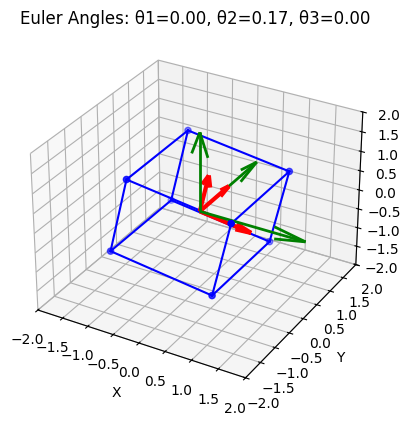

In [11]:
theta_1, theta_2, theta_3 = sm.symbols('theta_1, theta_2, theta_3')

N = ReferenceFrame('N')
B = ReferenceFrame('B')

B.orient_body_fixed(N, (theta_1, theta_2, theta_3), '321')

def rotation_matrix(theta_1, theta_2, theta_3):
    R1 = np.array([[1, 0, 0],
                   [0, np.cos(theta_1), -np.sin(theta_1)],
                   [0, np.sin(theta_1), np.cos(theta_1)]])
    
    R2 = np.array([[np.cos(theta_2), 0, np.sin(theta_2)],
                   [0, 1, 0],
                   [-np.sin(theta_2), 0, np.cos(theta_2)]])
    
    R3 = np.array([[np.cos(theta_3), -np.sin(theta_3), 0],
                   [np.sin(theta_3), np.cos(theta_3), 0],
                   [0, 0, 1]])

    return np.dot(R3, np.dot(R2, R1))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Cube
vertices = np.array([[-1, -1, -1],
                     [ 1, -1, -1],
                     [ 1,  1, -1],
                     [-1,  1, -1],
                     [-1, -1,  1],
                     [ 1, -1,  1],
                     [ 1,  1,  1],
                     [-1,  1,  1]])

def update_plot(theta_1_val, theta_2_val, theta_3_val):
    ax.cla()
    
    R = rotation_matrix(theta_1_val, theta_2_val, theta_3_val)
    
    rotated_vertices = np.dot(vertices, R.T)
    
    ax.scatter(rotated_vertices[:, 0], rotated_vertices[:, 1], rotated_vertices[:, 2], color='b')

    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]
    
    for edge in edges:
        ax.plot([rotated_vertices[edge[0], 0], rotated_vertices[edge[1], 0]],
                [rotated_vertices[edge[0], 1], rotated_vertices[edge[1], 1]],
                [rotated_vertices[edge[0], 2], rotated_vertices[edge[1], 2]], color='b')

    ax.quiver(0, 0, 0, 2, 0, 0, color='g', linewidth=2)
    ax.quiver(0, 0, 0, 0, 2, 0, color='g', linewidth=2)
    ax.quiver(0, 0, 0, 0, 0, 2, color='g', linewidth=2)

    rotated_axes = np.dot(np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]), R.T)
    ax.quiver(0, 0, 0, rotated_axes[0, 0], rotated_axes[0, 1], rotated_axes[0, 2], color='r', linewidth=3)
    ax.quiver(0, 0, 0, rotated_axes[1, 0], rotated_axes[1, 1], rotated_axes[1, 2], color='r', linewidth=3)
    ax.quiver(0, 0, 0, rotated_axes[2, 0], rotated_axes[2, 1], rotated_axes[2, 2], color='r', linewidth=3)

    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([-2, 2])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Euler Angles: θ1={theta_1_val:.2f}, θ2={theta_2_val:.2f}, θ3={theta_3_val:.2f}')
    
    plt.draw()

def animate(i):
    theta_1_val = np.radians(10 * np.sin(i * 0.1))
    theta_2_val = np.radians(10 * np.cos(i * 0.1))
    theta_3_val = np.radians(10 * np.sin(i * 0.1))
    
    update_plot(theta_1_val, theta_2_val, theta_3_val)

ani = animation.FuncAnimation(fig, animate, frames=200, interval=50)

ani.save('euler.gif', writer='imagemagick', fps=30)

---

# Exercises

## 4.
Consider the set of 232 Euler angles. Find the mapping of these angles $(\theta_1, \theta_2, \theta_3)$ to the corresponding ${[C]}$ DCM

In [6]:
N = ReferenceFrame('N')
C = ReferenceFrame('C')

th1, th2, th3 = sm.symbols('theta_1, theta_2, theta_3')
C = ReferenceFrame('C')
C.orient_body_fixed(N, (th1, th2, th3), 'YZY')

C.dcm(N)

Matrix([
[-sin(theta_1)*sin(theta_3) + cos(theta_1)*cos(theta_2)*cos(theta_3), sin(theta_2)*cos(theta_3), -sin(theta_1)*cos(theta_2)*cos(theta_3) - sin(theta_3)*cos(theta_1)],
[                                         -sin(theta_2)*cos(theta_1),              cos(theta_2),                                           sin(theta_1)*sin(theta_2)],
[ sin(theta_1)*cos(theta_3) + sin(theta_3)*cos(theta_1)*cos(theta_2), sin(theta_2)*sin(theta_3), -sin(theta_1)*sin(theta_3)*cos(theta_2) + cos(theta_1)*cos(theta_3)]])

## 5.

Consider the set of 232 Euler angles. Find appropriate inverse transformations from ${[C]}$ back to the 232 Euler angles.

$\theta_1 = tan^{-1}(\frac{C_{23}}{-C_{21}})$  
$\theta_2 = cos^{-1}(C_{22})$  
$\theta_3 = tan^{-1}(\frac{C_{32}}{C_{12}})$  